# Libraries

In [1]:
import pathlib as Path
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load_Dataset

In [2]:
raw_data=pd.read_csv("../data/raw/Customer_Segmentation.csv")
pre_processed_data=pd.read_csv("../data/processed/pre_processed_data.csv")
encoded_data=pd.read_csv("../data/processed/encoded_data.csv")

In [3]:
pre_processed_data

,Gender,Ever_Married,Graduated,Profession,Spending_Score,Var_1,Age,Work_Experience,Family_Size
0,Female,No,Yes,Healthcare,Low,Cat_6,32,9.0,3.0
1,Female,No,Yes,Artist,Low,Cat_6,56,0.0,1.0
2,Male,Yes,No,Lawyer,Low,Cat_4,75,1.0,1.0
3,Male,Yes,No,Entertainment,Low,Cat_3,39,9.0,2.0
4,Male,No,No,Healthcare,Low,Cat_4,22,9.0,5.0
...,...,...,...,...,...,...,...,...,...
10690,Female,No,Yes,Healthcare,Low,Cat_6,30,8.0,1.0
10691,Female,Yes,Yes,Lawyer,Average,Cat_6,81,0.0,2.0
10692,Female,No,Yes,Entertainment,Low,Cat_6,40,14.0,1.0
10693,Male,Yes,Yes,Lawyer,High,Cat_6,87,1.0,2.0


In [4]:
raw_data.isnull().sum()

Unnamed: 0            0
ID                    0
Gender                0
Ever_Married        190
Age                   0
Graduated           102
Profession          162
Work_Experience    1098
Spending_Score        0
Family_Size         448
Var_1               108
Segmentation          0
dtype: int64

### Sepration of Features

In [5]:
cat_raw_features=raw_data.select_dtypes("object")
cat_pro_features=pre_processed_data.select_dtypes("object")

In [6]:
num_raw_features=raw_data.select_dtypes("number")
num_pro_features=pre_processed_data.select_dtypes("number")

### EDA of Categorical_Features

In [7]:
def cat_graph(raw,pro):
    for col in pro.columns:
        plt.figure(figsize=(8,3))
        plt.subplot(1,2,1)
        sns.countplot(data=raw,x=raw[col])
        plt.title("Before Imputation")
        plt.xticks(rotation=90)
        plt.subplot(1,2,2)
        sns.countplot(data=pro,x=pro[col])
        plt.title("After Imputation")
        plt.xticks(rotation=90)
        plt.tight_layout()
        plt.show()
        

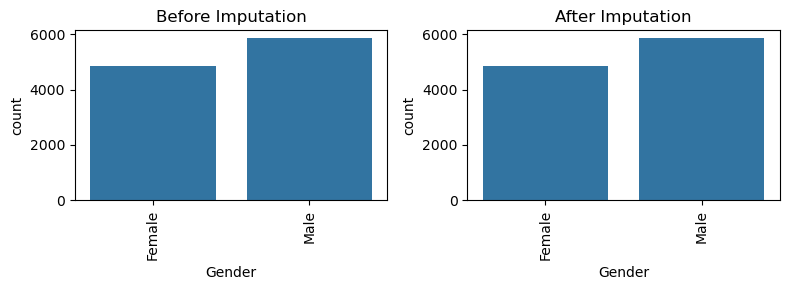

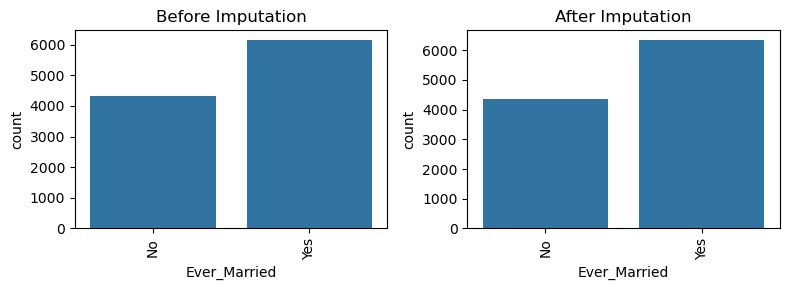

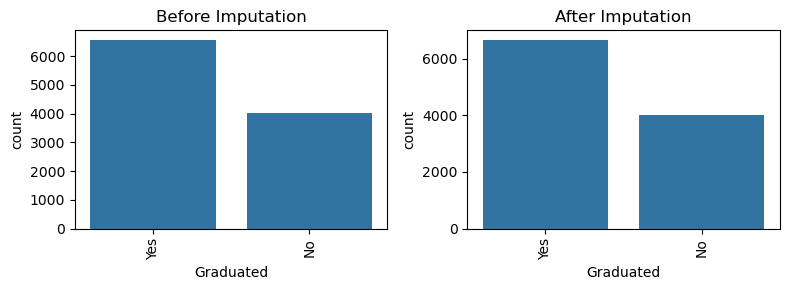

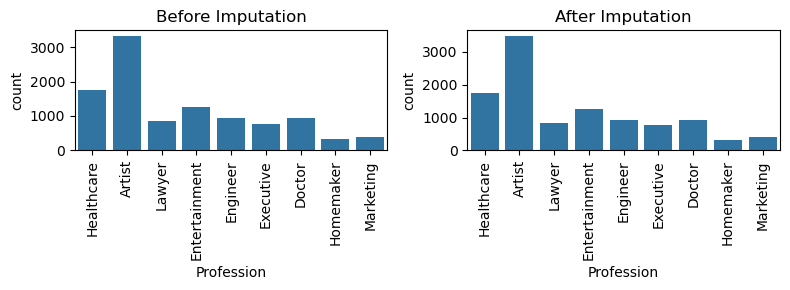

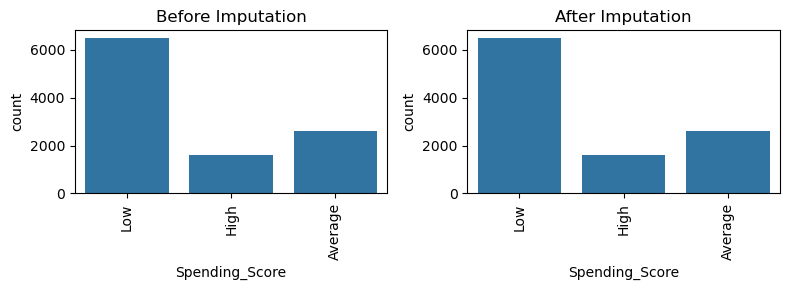

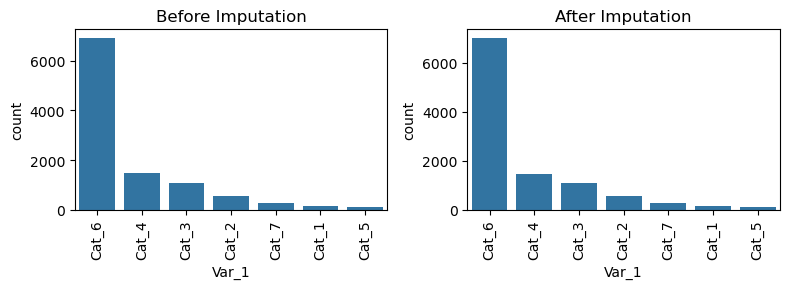

In [8]:
cat_graph(cat_raw_features,cat_pro_features)

Here is the the overall disribution of Dataset.Accroding to our datset we have the most number of Artist.

### EDA Of Numberical_Features

In [9]:
def num_graph(raw,pre):
    for col in pre.columns:
        if col=="Age":
            plt.figure(figsize=(8,3))
            plt.subplot(1,2,1)
            sns.histplot(data=raw,x=raw[col],bins=10)
            plt.title("Histogram")
            plt.subplot(1,2,2)
            sns.boxplot(data=raw,x=raw[col])
            plt.title("Boxplot")
            plt.tight_layout()
            plt.show()
        else:
            plt.figure(figsize=(8,3))
            plt.subplot(1,2,1)
            sns.countplot(data=raw,x=raw[col])
            plt.title("Before Imputation")
            plt.xticks(rotation=90)
            plt.subplot(1,2,2)
            sns.boxplot(data=raw,x=raw[col])
            plt.title("Boxplot")
            plt.xticks(rotation=90)
            plt.tight_layout()
            plt.show()
            plt.figure(figsize=(8,3))
            plt.subplot(1,2,1)
            sns.countplot(data=pre,x=pre[col])
            plt.title("After Imputation")
            plt.xticks(rotation=90)
            plt.subplot(1,2,2)
            sns.boxplot(data=pre,x=pre[col])
            plt.title("Boxplot")
            plt.xticks(rotation=90)
            plt.tight_layout()
            plt.show()

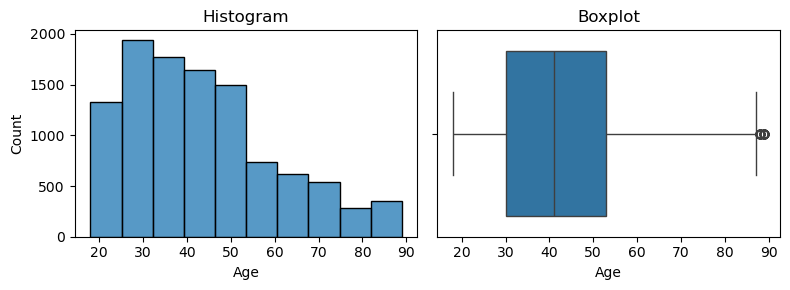

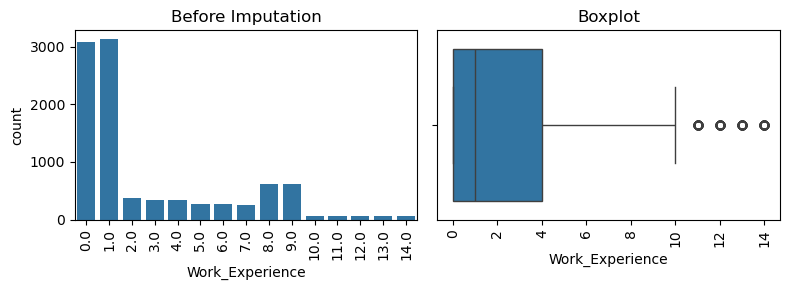

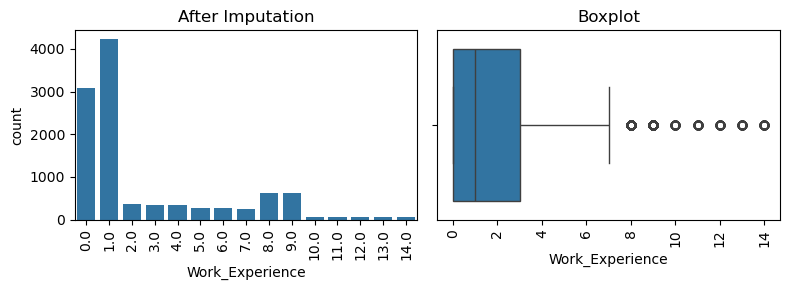

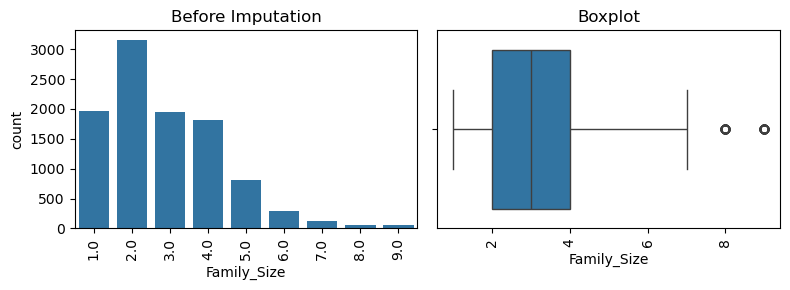

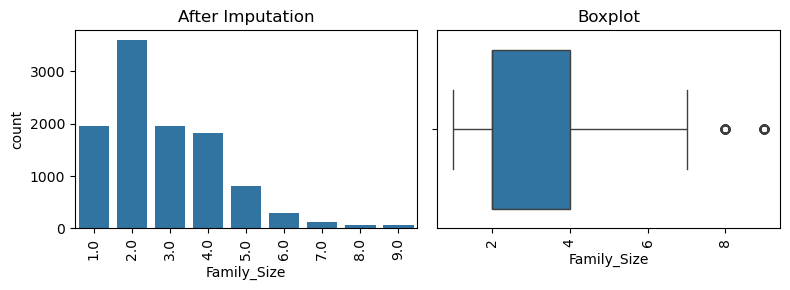

In [10]:
num_graph(num_raw_features,num_pro_features)

In [11]:
print("Max Age Outlier:",pre_processed_data["Age"].max())
print("Max Size of Family:",pre_processed_data["Family_Size"].max())
print("Max Work Experience:",pre_processed_data["Work_Experience"].max())

Max Age Outlier: 89
Max Size of Family: 9.0
Max Work Experience: 14.0


As given from the age factor we have some values that are outliers but those values are not anomalies,so they are not that much harmful to our analysis.so we will leave as it is.We have also outlier form Family Size and Work Experince but those number are very low and those are not anomaies ,so we can keep them as it it.

### Correlation

<Figure size 1000x400 with 0 Axes>

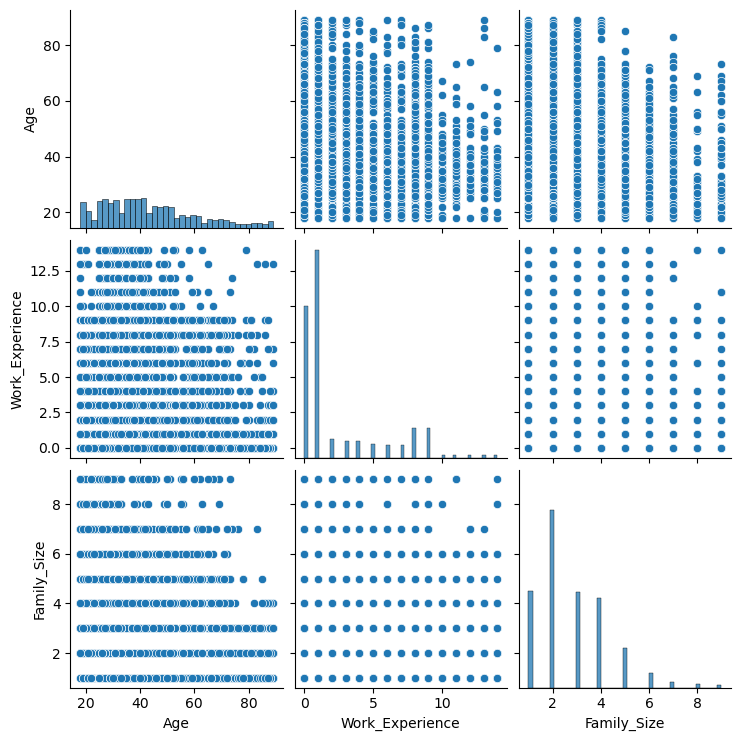

In [12]:
num=["Age","Work_Experience","Family_Size"]
plt.figure(figsize=(10,4))
sns.pairplot(data=pre_processed_data)
plt.savefig("../reports/figures/Pairplot.png")

Here we can see that in our numerical features we can see data have non linear relation between them moslty ,We will check through the corr.

In [13]:
encoded_data

,Gender_Male,Ever_Married_Yes,Graduated_Yes,Profession_Doctor,Profession_Engineer,Profession_Entertainment,Profession_Executive,Profession_Healthcare,Profession_Homemaker,Profession_Lawyer,...,Spending_Score_Low,Var_1_Cat_2,Var_1_Cat_3,Var_1_Cat_4,Var_1_Cat_5,Var_1_Cat_6,Var_1_Cat_7,Age,Work_Experience,Family_Size
0,0,0,1,0,0,0,0,1,0,0,...,1,0,0,0,0,1,0,32,9.0,3.0
1,0,0,1,0,0,0,0,0,0,0,...,1,0,0,0,0,1,0,56,0.0,1.0
2,1,1,0,0,0,0,0,0,0,1,...,1,0,0,1,0,0,0,75,1.0,1.0
3,1,1,0,0,0,1,0,0,0,0,...,1,0,1,0,0,0,0,39,9.0,2.0
4,1,0,0,0,0,0,0,1,0,0,...,1,0,0,1,0,0,0,22,9.0,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10690,0,0,1,0,0,0,0,1,0,0,...,1,0,0,0,0,1,0,30,8.0,1.0
10691,0,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,1,0,81,0.0,2.0
10692,0,0,1,0,0,1,0,0,0,0,...,1,0,0,0,0,1,0,40,14.0,1.0
10693,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,1,0,87,1.0,2.0


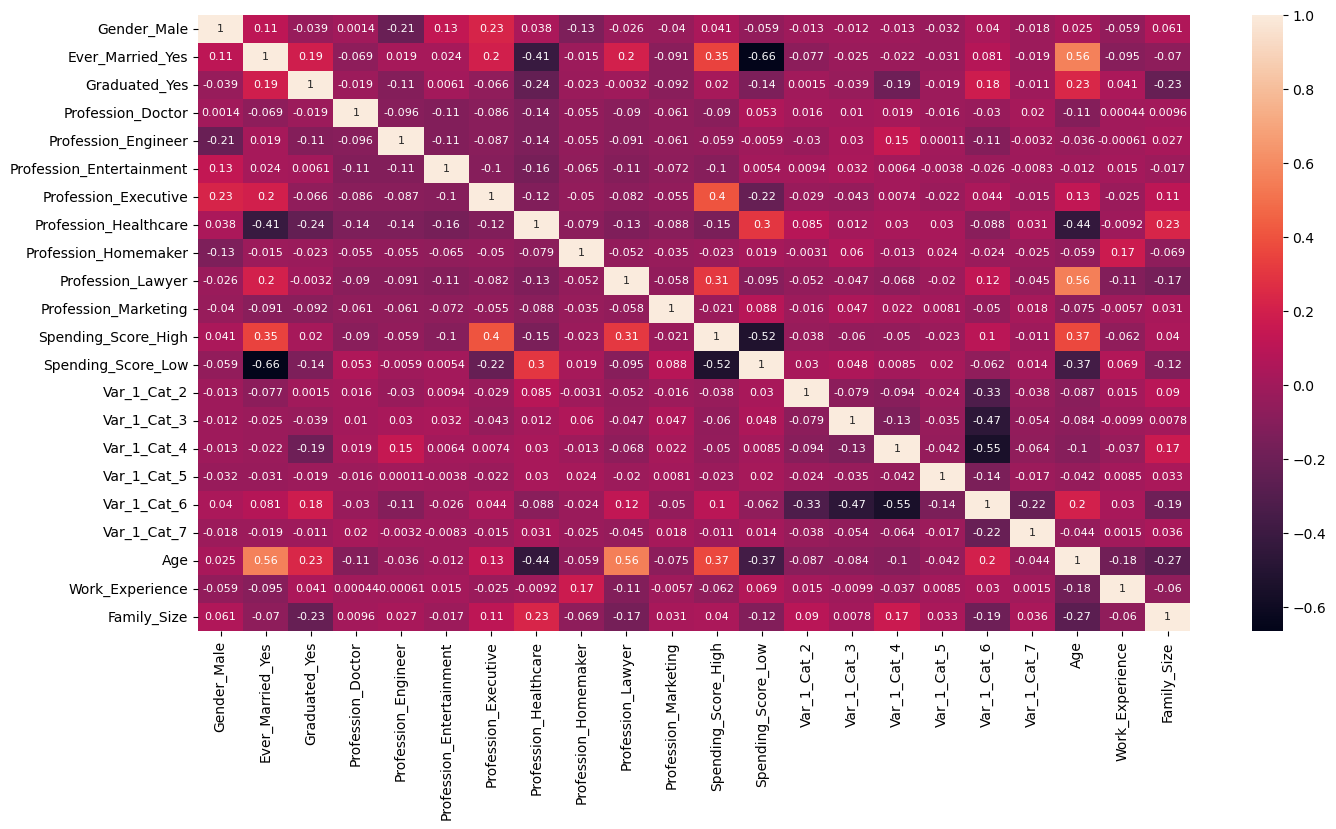

In [14]:
corrletion=encoded_data.corr()
plt.figure(figsize=(16,8))
sns.heatmap(data=corrletion,annot=True,annot_kws={"size":8})
plt.savefig("../reports/figures/Corelation_1.png")